# Análisis exploratorio de datos - Viajes en taxi de Nueva York (enero 2015)

Se realizó el procesamiento y limpieza del dataset `yellow_tripdata_2015-01.csv` para explorar los datos y preparar el posterior desarrollo de un modelo predictivo de la duración de un viaje. El dataset contaba con información de 12,7 M de viajes de enero de 2015, con un peso aproximado de 2 GB.

### Importar datos

Para el procesamiento de los datos, el archivo se lee por chunks y se limpia en el mismo recorrido. Se eligió esto, pues la RAM no permitía cargar todo en memoria de una sola pasada.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PATH = "../data/yellow_tripdata_2015-01.csv"
dt_cols = ["tpep_pickup_datetime", "tpep_dropoff_datetime"]
CHUNK = 3_000_000

def limpiar(chunk):
    trip_duration = (chunk["tpep_dropoff_datetime"] - chunk["tpep_pickup_datetime"]).dt.total_seconds()
    speed = chunk["trip_distance"] / (trip_duration / 3600)
    mask = (
        chunk["pickup_longitude"].between(-74.3, -73.7) & chunk["pickup_latitude"].between(40.5, 41.0) &
        chunk["dropoff_longitude"].between(-74.3, -73.7) & chunk["dropoff_latitude"].between(40.5, 41.0) &
        chunk["passenger_count"].between(1, 6) &
        chunk["trip_distance"].between(0.01, 100) &
        (speed <= 100) &
        (chunk["fare_amount"] > 0) &
        (chunk["total_amount"] >= chunk["fare_amount"]) &
        (chunk["VendorID"].isin([1, 2])) &
        (chunk["RateCodeID"].isin(range(1, 7))) &
        (chunk["payment_type"].isin(range(1, 5))) &
        chunk["store_and_fwd_flag"].isin(["Y", "N"]) &
        trip_duration.between(1, 6 * 3600)
    )
    out = chunk.loc[mask].dropna().drop_duplicates()
    out["trip_duration_min"] = (out["tpep_dropoff_datetime"] - out["tpep_pickup_datetime"]).dt.total_seconds() / 60
    return out

### Limpieza de datos

Se descartan los registros que no cumplen los criterios de validez, para evitar errores en las medidas de las etapas siguientes:
- Coordenadas de partida/llegada fuera del área de Nueva York.
- `passenger_count` fuera de [1, 6].
- `trip_distance` no positiva o > 100 mi (el dataset contiene valores absurdos de millones de millas).
- Velocidad media implausible (> 100 mph), por inconsistencia entre distancia y duración.
- `trip_duration` fuera de (0, 6 h].
- Tarifas inválidas (`fare_amount` ≤ 0 o `total_amount < fare_amount`).
- Códigos fuera de rango (`VendorID`, `RateCodeID`, `payment_type`, `store_and_fwd_flag`).
- Filas duplicadas o con valores nulos.

In [29]:
total_rows = 0
nulls = None
clean = []
for chunk in pd.read_csv(PATH, parse_dates=dt_cols, chunksize=CHUNK):
    total_rows += len(chunk)
    nulls = chunk.isna().sum() if nulls is None else nulls.add(chunk.isna().sum())
    clean.append(limpiar(chunk))

df = pd.concat(clean, ignore_index=True)
del clean

print(f"Filas antes: {total_rows:,}")
print(f"Filas después: {len(df):,}")
print(f"Porcentaje eliminado: {(1 - len(df) / total_rows) * 100:.2f}%")
print("Nulos por columna (datos originales):")
print(nulls[nulls > 0])

Filas antes: 11,124,437
Filas después: 10,822,310
Porcentaje eliminado: 2.72%
Nulos por columna (datos originales):
RateCodeID               1
store_and_fwd_flag       1
dropoff_longitude        1
dropoff_latitude         1
payment_type             1
fare_amount              1
extra                    1
mta_tax                  1
tip_amount               1
tolls_amount             1
improvement_surcharge    4
total_amount             1
dtype: int64


### Estadísticas descriptivas (datos limpios)

In [30]:
df.describe().round(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration_min
count,10822310.00,10822310,10822310,10822310.00,10822310.00,10822310.00,10822310.00,10822310.00,10822310.00,10822310.00,10822310.00,10822310.00,10822310.00,10822310.00,10822310.00,10822310.00,10822310.00,10822310.00,10822310.00
mean,1.53,2015-01-16 15:06:58.290773,2015-01-16 15:19:20.116600,1.69,2.79,-73.97,40.75,1.02,-73.97,40.75,1.38,11.83,0.31,0.50,1.90,0.24,0.28,15.07,12.36
min,1.00,2015-01-01 00:00:00,2015-01-01 00:01:25,1.00,0.01,-74.30,40.52,1.00,-74.30,40.50,1.00,0.01,-0.40,0.00,0.00,0.00,0.00,0.01,0.02
25%,1.00,2015-01-09 08:14:54,2015-01-09 08:34:35.250000,1.00,1.00,-73.99,40.74,1.00,-73.99,40.74,1.00,6.50,0.00,0.50,0.00,0.00,0.30,8.30,6.17
50%,2.00,2015-01-16 12:11:54,2015-01-16 12:25:48,1.00,1.69,-73.98,40.75,1.00,-73.98,40.75,1.00,9.00,0.00,0.50,1.00,0.00,0.30,11.16,10.00
75%,2.00,2015-01-23 19:20:58,2015-01-23 19:34:27,2.00,3.00,-73.97,40.77,1.00,-73.96,40.77,2.00,13.50,0.50,0.50,2.07,0.00,0.30,16.30,15.83
max,2.00,2015-01-31 23:59:59,2015-02-01 01:09:52,6.00,99.90,-73.70,41.00,6.00,-73.70,41.00,4.00,3005.50,648.02,0.50,3950588.80,1000.66,0.30,3950611.60,359.97
std,0.50,NaN,NaN,1.34,3.34,0.04,0.03,0.20,0.03,0.03,0.49,9.55,0.53,0.02,1200.89,1.34,0.07,1200.95,9.32


In [31]:
for col in ["VendorID", "RateCodeID", "store_and_fwd_flag", "payment_type"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- VendorID ---
VendorID
2    5717221
1    5105089
Name: count, dtype: int64

--- RateCodeID ---
RateCodeID
1.0    10611342
2.0      183983
3.0       14002
5.0       10968
4.0        1980
6.0          35
Name: count, dtype: int64

--- store_and_fwd_flag ---
store_and_fwd_flag
N    10730045
Y       92265
Name: count, dtype: int64

--- payment_type ---
payment_type
1.0    6716909
2.0    4076306
3.0      22385
4.0       6710
Name: count, dtype: int64



### Gráficas

Los gráficos se realizaron sobre una muestra aleatoria limpia de 8 M de viajes. Las variables numéricas se recortan a su percentil 99 únicamente para mejorar la visualización.

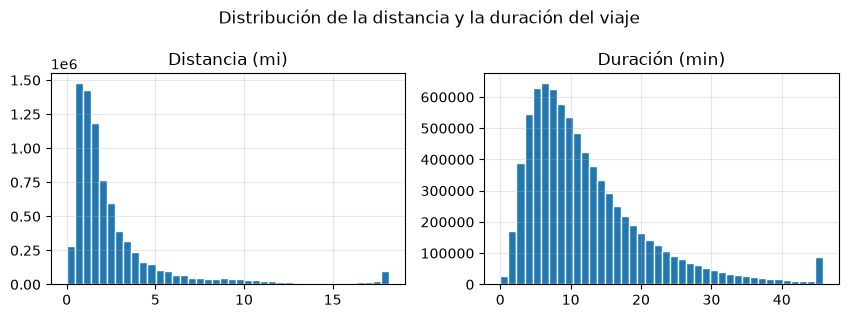

In [32]:
labels = {
    "trip_distance": "Distancia (mi)", "trip_duration_min": "Duración (min)",
    "pickup_hour": "Hora de partida", "fare_amount": "Precio (USD)",
}

df = df.sample(n=8_000_000, random_state=67)

plot_df = df[["trip_distance", "trip_duration_min", "fare_amount"]].copy()
for col in ["trip_distance", "trip_duration_min", "fare_amount"]:
    plot_df[col] = plot_df[col].clip(upper=plot_df[col].quantile(0.99))
plot_df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour

hist_features = ["trip_distance", "trip_duration_min"]
axes = plot_df[hist_features].rename(columns=labels).hist(figsize=(8.5, 3.2), bins=40, edgecolor="white")
for ax in axes.ravel():
    ax.grid(alpha=0.3)
plt.suptitle("Distribución de la distancia y la duración del viaje")
plt.tight_layout()
plt.show()

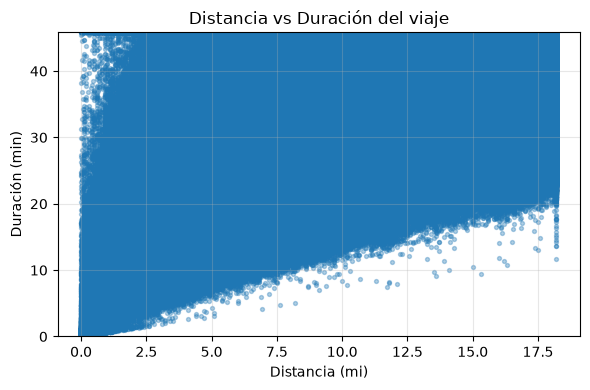

In [33]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(plot_df["trip_distance"], plot_df["trip_duration_min"], s=8, alpha=0.35, rasterized=True)
ax.set_xlabel("Distancia (mi)")
ax.set_ylabel("Duración (min)")
ax.set_ylim(0, plot_df["trip_duration_min"].quantile(0.99))
ax.grid(alpha=0.3)
plt.title("Distancia vs Duración del viaje")
plt.tight_layout()
plt.show()

In [34]:
dur_q = df["trip_duration_min"].quantile([0.25, 0.5, 0.75, 0.99])
print("Cuantiles de trip_duration (min):")
print(dur_q.round(2))
print(f"Media: {df['trip_duration_min'].mean():.2f} min")
print(f"% de viajes por encima del P99: {(df['trip_duration_min'] > dur_q.loc[0.99]).mean():.4f}")

Cuantiles de trip_duration (min):
0.25     6.17
0.50    10.00
0.75    15.82
0.99    45.83
Name: trip_duration_min, dtype: float64
Media: 12.36 min
% de viajes por encima del P99: 0.0100


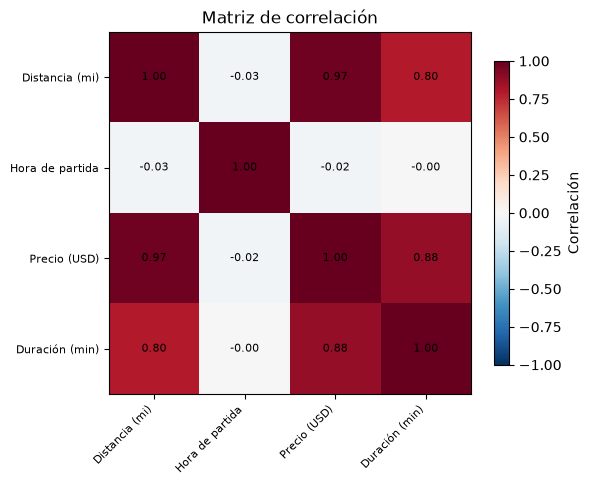

In [35]:
corr = plot_df[["trip_distance", "pickup_hour", "fare_amount", "trip_duration_min"]].rename(columns=labels).corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8, label="Correlación")
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

### Hora de partida y día de la semana

Duración mediana por hora de partida (24 intervalos) y por día de la semana (Lun–Dom).

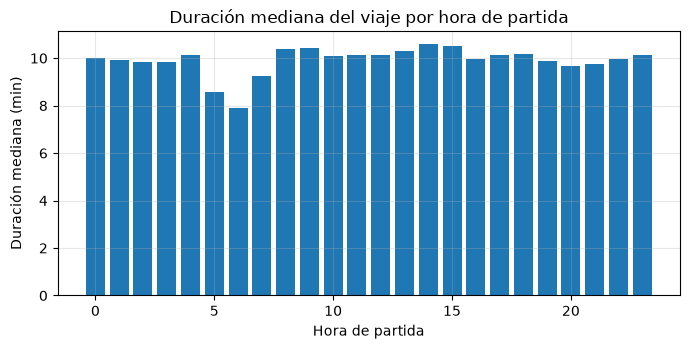

In [36]:
dur_hour = df.groupby(df["tpep_pickup_datetime"].dt.hour)["trip_duration_min"].median()

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(dur_hour.index, dur_hour.values)
ax.set_xlabel("Hora de partida")
ax.set_ylabel("Duración mediana (min)")
ax.set_title("Duración mediana del viaje por hora de partida")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

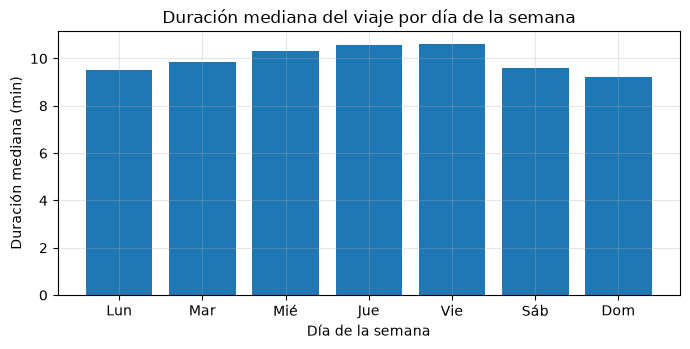

In [37]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_labels = {d: s for d, s in zip(day_order, ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"])}

dur_weekday = df.groupby(df["tpep_pickup_datetime"].dt.day_name())["trip_duration_min"].median().reindex(day_order)
dur_weekday.index = [day_labels[d] for d in day_order]

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(dur_weekday.index, dur_weekday.values)
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Duración mediana (min)")
ax.set_title("Duración mediana del viaje por día de la semana")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Ubicación de partida y llegada

Duración mediana por celda hexagonal según las coordenadas de partida y de llegada.

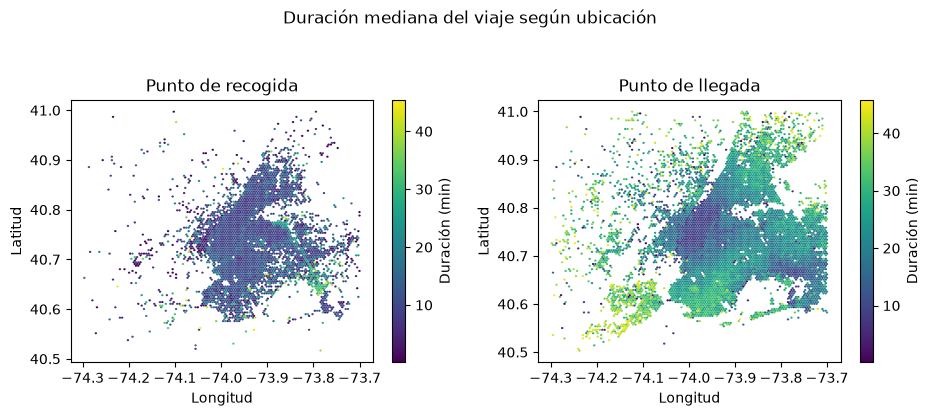

In [38]:
geo = df[df["trip_duration_min"] <= df["trip_duration_min"].quantile(0.99)]
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))

hb = axes[0].hexbin(geo["pickup_longitude"], geo["pickup_latitude"], C=geo["trip_duration_min"],
                    reduce_C_function=np.median, gridsize=120, cmap="viridis", mincnt=1, linewidths=0)
axes[0].set_title("Punto de recogida")
axes[0].set_xlabel("Longitud"); axes[0].set_ylabel("Latitud")
fig.colorbar(hb, ax=axes[0], label="Duración (min)")

hb2 = axes[1].hexbin(geo["dropoff_longitude"], geo["dropoff_latitude"], C=geo["trip_duration_min"],
                     reduce_C_function=np.median, gridsize=120, cmap="viridis", mincnt=1, linewidths=0)
axes[1].set_title("Punto de llegada")
axes[1].set_xlabel("Longitud"); axes[1].set_ylabel("Latitud")
fig.colorbar(hb2, ax=axes[1], label="Duración (min)")

plt.suptitle("Duración mediana del viaje según ubicación")
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

### Exportar dataset limpio

Tras aplicar la misma limpieza a todo el dataset, se guardó en `yellow_tripdata_2015-01_clean.csv` para su futuro procesamiento con nuestro modelo predictivo.

In [39]:
clean_path = "../data/yellow_tripdata_2015-01_clean.csv"

pd.read_csv(PATH, nrows=0).to_csv(clean_path, index=False)
for chunk in pd.read_csv(PATH, parse_dates=dt_cols, chunksize=CHUNK):
    limpiar(chunk).to_csv(clean_path, mode="a", header=False, index=False)

print("Dataset limpio guardado en:", clean_path)

Dataset limpio guardado en: ../data/yellow_tripdata_2015-01_clean.csv
